# Event-grounded commentary taxonomy — end-to-end method run

One notebook that runs the **computational analysis pipeline and principal
validation stages** of the study: corpus + masking, taxonomy induction, vocabulary
enrichment, the robustness validation protocol, domain structure, held-out coverage,
the leftover partition and its session-shuffle null. The human-rater study is not
re-administered here.

**What this notebook is.** It executes the computational analysis pipeline and
principal validation stages on the selected corpus. Validation stages are
configuration-dependent: the shipped iRacing preset disables Axis 3 by default,
while the paper F1 configuration retains the full four-axis protocol.
Reproducing the paper's Formula 1 numerical results
requires the F1 corpus, which is under broadcast copyright and is not
redistributed; its configuration is recorded in `pipeline/config.py`. A
different corpus yields different clusters, so the numbers below are the
demonstration run's own.

**Two run modes** (one switch, next cell):

| mode | behaviour |
|---|---|
| `prepared` | reuse anything already in `results/cache` — minutes |
| `scratch`  | recompute every stage from the raw corpus — much slower |

**Corpus-agnostic by design.** The notebook derives corpus-specific keyword
handles (`K00`, `K01`, …) and exemplar sentences automatically. The thematic
labels and broad-domain assignments reported in the paper are human-authored
reference artefacts and are not regenerated automatically by the clustering
pipeline. An optional `data/label_map.json` can attach external labels if you
have them.

The shipped corpus is **iRacing broadcast commentary** (CC-BY 3.0,
redistributable), and every sentence carries the recording it came from — so
each exemplar quoted below names its source video. The F1 corpora used in the
paper are broadcast-copyright and cannot be redistributed; `sentences_path`
accepts your own licensed copy if you hold one.

## 0 · Configuration

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

from pipeline import Config, for_corpus
from pipeline import (corpus, embedding, clustering, enrichment, labeling,
                      validation, domains, coverage, ablation, reporting, axis3)
from pipeline.io_utils import save_table
import numpy as np, pandas as pd
from pathlib import Path

# ---- switch corpus here: "iracing" (ships) | "f1_highlights" | "f1_full" ----
CORPUS = "iracing"

cfg = for_corpus(
    CORPUS,
    # ---- run mode: "prepared" (reuse cache) or "scratch" (recompute all) ---
    mode="prepared",
    use_ner_fallback=False,

    # ---- cost knobs (raise for the full protocol) ------------------------
    r3_n_permutations=1000,
    bootstrap_n=30,
    axis4_n_replicates=10,
    null_n_permutations=1000,

    limit_sentences=None,   # set e.g. 1500 for a fast smoke run
)

# Optional extras -----------------------------------------------------------
ALT_ENCODER   = "sentence-transformers/all-mpnet-base-v2"  # cross-encoder check
RUN_ABLATIONS = True    # masking + cross-encoder + default-pipeline (each re-embeds)
DEFAULT_MCS   = 10      # library default granularity, for the out-of-the-box contrast
cfg.seed_everything()
cfg.save()   # writes run_config.json to the kit root
print(f"corpus={cfg.corpus_name}   mode={cfg.mode}   seed={cfg.seed}")
print(f"cache -> {cfg.cache_dir.relative_to(Path.cwd())}")

corpus=iracing   mode=prepared   seed=42
cache -> results\iracing\cache


## 1 · Corpus and entity masking

Masking runs **before** embedding: every downstream number is computed over
masked text, which reduces dependence on recognised entity names.

In [2]:
df = corpus.load_corpus(cfg)
df = corpus.apply_masking(cfg, df)

mask_rep = corpus.masking_report(df)
save_table(cfg, mask_rep, "masking_report")

corpus_stats = pd.DataFrame([{
    "sentences": len(df),
    "sessions": df["session"].nunique(),
    "mean_sentences_per_session": round(len(df) / df["session"].nunique(), 1),
    "min_per_session": int(df.groupby("session").size().min()),
    "max_per_session": int(df.groupby("session").size().max()),
    "masked_sentences": int(df["masked"].str.contains("<", regex=False).sum()),
}])
save_table(cfg, corpus_stats, "corpus_stats")

# Every sentence keeps the recording it came from, so any quoted line is traceable.
prov = corpus.provenance_table(df)
save_table(cfg, prov, "source_provenance")
SOURCES = corpus.source_labels(df)          # origin label, for source columns
SOURCED = corpus.with_source(df, df["text"]) # sentence + origin, for bare-sentence output

reporting.show(corpus_stats, title="Corpus")
reporting.show(prov, n=30, title="Source recordings behind this corpus")
reporting.show(mask_rep, title="Masking coverage")
_cols = [c for c in ["session", "video_title", "upload_date", "text", "masked"]
         if c in df.columns]
reporting.show(df[_cols].head(5), title="Masking examples, with their source")

[    0.7s] corpus: 5,967 sentences across 8 sessions [sentences.jsonl]


[    0.7s] corpus: provenance carried - video_id, video_url, video_title, channel, upload_date, series, license_spdx


[    0.9s] masking: cache verified against source (5,967 rows)


[    0.9s] masking: 1,366/5,967 sentences carry >=1 placeholder


[    1.0s] table   -> masking_report.csv  (4 rows)


...

,video_id,sentences,video_url,video_title,channel,upload_date,series,license_spdx,pct_of_corpus
0,pdRjO3MUTGQ,1026,https://www.youtube.com/watch?v=pdRjO3MUTGQ,Victory Lane Outlaws Truck Series,Fearless Broadcasting,2026-05-19,VLO_Truck,CC-BY-3.0,17.2
1,1sIEltYU9jY,923,https://www.youtube.com/watch?v=1sIEltYU9jY,Friday Night O'Reilly Auto Parts Racing League,Fearless Broadcasting,2026-05-30,FNO,CC-BY-3.0,15.5
2,VreR8mdkPH0,882,https://www.youtube.com/watch?v=VreR8mdkPH0,Victory Lane Outlaws,Fearless Broadcasting,2026-05-12,VLO,CC-BY-3.0,14.8
3,HHJ0cIAJdGY,740,https://www.youtube.com/watch?v=HHJ0cIAJdGY,Victory Lane Outlaws,Fearless Broadcasting,2026-05-15,VLO,CC-BY-3.0,12.4
4,oCeIXraAyDI,685,https://www.youtube.com/watch?v=oCeIXraAyDI,Friday Night O'Reilly Auto Parts Racing League,Fearless Broadcasting,2026-05-23,FNO,CC-BY-3.0,11.5
5,jixEvBux-zs,628,https://www.youtube.com/watch?v=jixEvBux-zs,Victory Lane Outlaws,Fearless Broadcasting,2026-05-22,VLO,CC-BY-3.0,10.5
6,VYTJiGWe4fo,543,https://www.youtube.com/watch?v=VYTJiGWe4fo,Victory Lane Outlaws,Fearless Broadcasting,2026-05-29,VLO,CC-BY-3.0,9.1
7,HFU-A6Rwoeg,540,https://www.youtube.com/watch?v=HFU-A6Rwoeg,Victory Lane Outlaws Truck Series,Fearless Broadcasting,2026-06-05,VLO_Truck,CC-BY-3.0,9.0


**Masking coverage**

,placeholder,sentences,occurrences
0,<PERSON>,1320,1554
1,<TEAM>,26,26
2,<PLACE>,30,31
3,any,1366,1611


**Masking examples, with their source**

,session,video_title,upload_date,text,masked
0,VYTJiGWe4fo,Victory Lane Outlaws,2026-05-29,So here we go.,So here we go.
1,VYTJiGWe4fo,Victory Lane Outlaws,2026-05-29,We're back out in the front again.,We're back out in the front again.
2,VYTJiGWe4fo,Victory Lane Outlaws,2026-05-29,Stephen has it has jumped out in front of everyone.,<PERSON> has jumped out in front of everyone.
3,VYTJiGWe4fo,Victory Lane Outlaws,2026-05-29,"Bo Guggley is trying to keep pace with everyone, but he's trying t...","<PERSON> is trying to keep pace with everyone, but he's trying to ..."
4,VYTJiGWe4fo,Victory Lane Outlaws,2026-05-29,He's about little over two seconds behind the leader.,He's about little over two seconds behind the leader.


## 2 · Embedding, granularity sweep, partition

The sweep is the evidence for the chosen `min_cluster_size`: the plateau is
located from the data, not asserted.

[    1.0s] cache hit  iracing__emb__all_MiniLM_L6_v2.npy


[    1.1s] embeddings: (5967, 384)


[    1.1s] cache hit  iracing__umap__s42.npy


[    1.1s] umap: (5967, 5)


[    1.1s] cache hit  iracing__mcs_sweep.csv


...

**Granularity sweep**

,min_cluster_size,n_clusters,noise_pct,largest_cluster
0,10,148,25.825373,216
1,15,103,32.277526,200
2,20,70,31.020613,379
3,25,56,34.137758,363
4,30,46,38.159879,359
5,35,31,40.254734,397
6,40,18,23.495894,2346
7,45,8,13.038378,2297
8,50,8,14.362326,2259
9,55,13,28.506787,1950


**Primary partition**

,min_cluster_size,n_clusters,noise_pct,clustered_sentences,plateau_lo,plateau_hi
0,35,31,40.3,3565,35,35


[    1.5s] figure  -> fig_granularity_sweep.png


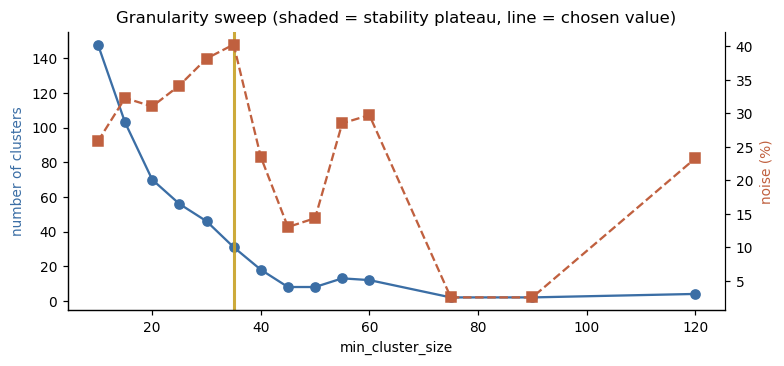

In [3]:
X = embedding.embed(cfg, df["masked"])
U = clustering.reduce_umap(cfg, X)

sweep = clustering.mcs_sweep(cfg, U)
save_table(cfg, sweep, "granularity_sweep")

labels = clustering.partition(cfg, U)
plateau = clustering.plateau_summary(sweep, cfg.min_cluster_size)

partition_stats = pd.DataFrame([{
    "min_cluster_size": cfg.min_cluster_size,
    "n_clusters": clustering.n_clusters(labels),
    "noise_pct": round(100 * clustering.noise_rate(labels), 1),
    "clustered_sentences": int((labels != -1).sum()),
    "plateau_lo": plateau.get("plateau_lo"),
    "plateau_hi": plateau.get("plateau_hi"),
}])
save_table(cfg, partition_stats, "partition_stats")

reporting.show(sweep, n=30, title="Granularity sweep")
reporting.show(partition_stats, title="Primary partition")
_, fig = reporting.fig_mcs_sweep(cfg, sweep, plateau); fig

## 3 · Vocabulary enrichment and cluster identity

An exact one-sided hypergeometric test with a single global Benjamini-Hochberg
family gives each cluster its vocabulary signature; the signature *is* the
cluster's name here.

[    1.7s] cache hit  iracing__r3_enrichment.csv


[    1.7s] r3: 656 significant (cluster, term) pairs, 50% bigrams (exact hypergeometric, global BH)


[    1.7s] table   -> r3_enrichment.csv  (656 rows)


[    1.7s] label map not found (label_map.json) — using derived keyword identity only


[    1.8s] cards: 31 clusters, top-5 hold 41.2% of clustered sentences


...

**Cluster cards (identity derived from the corpus)**

,handle,size,share_of_clustered,keywords,n_enriched
0,K00,397,0.111360,grab / comes / right / going advantage,4
1,K01,321,0.090042,laps / stage / 100 / number,83
2,K02,272,0.076297,pit / tires / fuel / road,61
3,K03,272,0.076297,try / inside / going / wants,14
4,K04,205,0.057504,car / truck / driving / ram,38
5,K05,205,0.057504,racing / race / guys / hard,31
6,K06,195,0.054698,guys / going thing / follow / happening,19
7,K07,132,0.037027,13 / 14 / 12 / 22,8
8,K08,114,0.031978,look / quick / let / happened,21
9,K09,107,0.030014,happens / folks / wait / ll,15


**Enriched terms per cluster - spread**

,value
clusters,31.000
vocabulary_terms,2030.000
candidate_pairs,62930.000
total_enriched_pairs,656.000
mean_per_cluster,21.200
median_per_cluster,14.000
min_per_cluster,3.000
max_per_cluster,83.000
clusters_with_zero,0.000
frac_clusters_ge5_terms,0.935


[    3.4s] figure  -> fig_cluster_sizes.png


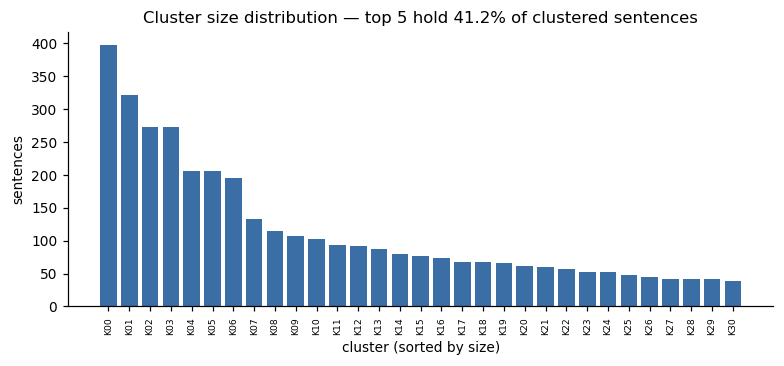

In [4]:
enr = enrichment.r3_enrichment(cfg, df["masked"], labels)
save_table(cfg, enr, "r3_enrichment")

label_map = labeling.load_label_map("data/label_map.json")   # optional, absent by default
cards = labeling.build_cluster_cards(cfg, X, labels, df["text"].tolist(), enr, label_map,
                                     sources=SOURCES)
save_table(cfg, cards, "cluster_cards")

enr_summary = enrichment.enrichment_summary(enr, labels)
save_table(cfg, enr_summary, "enrichment_summary")

vocab_n = enrichment.vocabulary_size(cfg, df["masked"])
enr_spread = pd.DataFrame([{
    "clusters": len(enr_summary),
    "vocabulary_terms": vocab_n,
    "candidate_pairs": vocab_n * len(enr_summary),
    "total_enriched_pairs": int(enr_summary["n_enriched"].sum()),
    "mean_per_cluster": round(float(enr_summary["n_enriched"].mean()), 1),
    "median_per_cluster": float(enr_summary["n_enriched"].median()),
    "min_per_cluster": int(enr_summary["n_enriched"].min()),
    "max_per_cluster": int(enr_summary["n_enriched"].max()),
    "clusters_with_zero": int((enr_summary["n_enriched"] == 0).sum()),
    # the "interpretability fraction": share of clusters with a usable signature
    "frac_clusters_ge5_terms": round(float((enr_summary["n_enriched"] >= 5).mean()), 3),
    "pct_bigram": round(100 * float(enr_summary["pct_bigram"].mean()), 1),
}])
save_table(cfg, enr_spread, "enrichment_spread")

reporting.show(cards[["handle", "size", "share_of_clustered", "keywords", "n_enriched"]],
               n=40, title="Cluster cards (identity derived from the corpus)")
reporting.show(enr_spread.T.rename(columns={0: "value"}), n=12,
               title="Enriched terms per cluster - spread")
_, fig = reporting.fig_size_distribution(cfg, cards); fig

In [5]:
# Cluster-count stability alone cannot pick a point inside a plateau. The paper's
# granularity-selection richness diagnostic is the sweep's log-odds screen; the
# exact FDR-corrected R3 measured here is a POST-SELECTION auxiliary diagnostic,
# not the tie-breaker that chose mcs=35.
grid = sorted(cfg.mcs_sweep)
lo = plateau.get("plateau_lo") or cfg.min_cluster_size
hi = plateau.get("plateau_hi") or cfg.min_cluster_size
plateau_mcs = [m for m in grid if lo <= m <= hi]
if len(plateau_mcs) < 3:   # a one-point plateau says nothing; widen to its neighbours
    i = grid.index(cfg.min_cluster_size)
    plateau_mcs = grid[max(0, i - 2):i + 3]
richness = enrichment.enrichment_across_plateau(cfg, df["masked"], U, plateau_mcs)
save_table(cfg, richness, "enrichment_richness")
reporting.show(richness, n=12,
               title="Signature richness across the plateau (exact hypergeometric)")

[    3.6s] cache hit  iracing__enrichment_richness.csv


[    3.6s] table   -> enrichment_richness.csv  (5 rows)


**Signature richness across the plateau (exact hypergeometric)**

,min_cluster_size,n_clusters,enriched_pairs,mean_per_cluster,clusters_with_zero,frac_clusters_ge5_terms
0,25,56,881,15.7,1,0.911
1,30,46,705,15.3,1,0.891
2,35,31,656,21.2,0,0.935
3,40,18,514,28.6,0,0.944
4,45,8,480,60.0,0,1.000


In [6]:
# The paper reports a heavy tail; this is the concentration behind that word.
sizes = cards["size"].sort_values(ascending=False).to_numpy()
total = int(sizes.sum())
concentration = pd.DataFrame([{
    "clustered_sentences": total,
    "top1_pct": round(100 * sizes[:1].sum() / total, 1),
    "top5_pct": round(100 * sizes[:5].sum() / total, 1),
    "top10_pct": round(100 * sizes[:10].sum() / total, 1),
    "largest": int(sizes[0]), "smallest": int(sizes[-1]),
    "median": float(pd.Series(sizes).median()),
    "gini": round(float((2 * (np.arange(1, len(sizes) + 1) * np.sort(sizes)).sum())
                        / (len(sizes) * total) - (len(sizes) + 1) / len(sizes)), 3),
}])
save_table(cfg, concentration, "size_concentration")
reporting.show(concentration.T.rename(columns={0: "value"}), n=12,
               title="Cluster-size concentration")

[    3.7s] table   -> size_concentration.csv  (1 rows)


**Cluster-size concentration**

,value
clustered_sentences,3565.000
top1_pct,11.100
top5_pct,41.200
top10_pct,62.300
largest,397.000
smallest,38.000
median,76.000
gini,0.388


In [7]:
# Full card for the largest cluster — keywords + exemplars, no external naming
top = cards.iloc[0]
print(labeling.display_name(top))
print(f"size={top['size']}  enriched terms={top['n_enriched']}")
for i in (1, 2, 3):
    if top[f"exemplar_{i}"]:
        print(f"  {i}. {top[f'exemplar_{i}']}")
        src = top.get(f"exemplar_{i}_source", "")
        if src:
            print(f"     source: {src}")

K00 · grab / comes / right / going advantage
size=397  enriched terms=4
  1. Joshua Smith is right there.
     source: Victory Lane Outlaws Truck Series, 2026-05-19
  2. James Greco is right there.
     source: Victory Lane Outlaws Truck Series, 2026-05-19
  3. There is Tim Abro.
     source: Victory Lane Outlaws, 2026-05-12


## 4 · Robustness validation

Each axis perturbs a different source of contingency. A cluster's verdict band
is simply how many axis criteria it meets — no hand-assigned status anywhere.

The shipped iRacing configuration runs three enabled axes by default. Axis 3
(held-out session replication) is optional and can be enabled in the
configuration. The paper F1 configuration uses all four axes.

Axis 3 works on a session-level train/test split: UMAP and HDBSCAN are refitted
on the training sessions only, the reconstructed clusters are Hungarian-aligned
to the full-corpus identifiers, held-out sentences are assigned by HDBSCAN
approximate prediction, and the lexical signatures are then re-tested on the
held-out side. A cluster meets the criterion only when `rep_strict` and
`rep_dir` are both at or above the threshold. This is a reconstruction test, not
the nearest-centroid assignment used for coverage in section 6.

The seven paper judges determine the Axis-1 score; resolution and UMAP-seed
variants are auxiliary diagnostics and are not scored.

In [8]:
a1 = validation.axis1_algorithm(cfg, X, U, labels, texts=df["masked"])
a2 = validation.axis2_bootstrap(cfg, X, labels)

if cfg.axis3_enabled:
    a3 = axis3.axis3_heldout_replication(cfg, df, X, labels)
else:
    a3 = None
    print("Axis 3 - Held-out session replication")
    print("  SKIPPED")
    print("  Reason: disabled by configuration (axis3_enabled = false)")
    print("  Enable with: for_corpus(CORPUS, axis3_enabled=True)")

a4 = validation.axis4_hierarchical(cfg, X, labels)

verdict = validation.combine_axes(cfg, a1, a2, a3, a4)
verdict = verdict.merge(cards[["cluster", "handle", "keywords"]], on="cluster")
save_table(cfg, verdict, "verdict_per_cluster")

counts = validation.axis_counts(verdict)
bands, cumulative = validation.verdict_summary(verdict)
corr = validation.axis_correlations(verdict)
for nm, t in [("axis_counts", counts), ("verdict_bands", bands),
              ("cumulative", cumulative), ("axis_correlations", corr)]:
    save_table(cfg, t, nm)

# A judge that failed to construct would silently shrink the Axis-1 denominator,
# so the roster is asserted here rather than left to a log line.
if "axis1_complete" not in a1.columns:
    # cache written before the roster check existed
    print("NOTE - axis1 cache predates the judge-roster check; "
          "delete results/cache/*axis1* to record it.")
elif not bool(a1["axis1_complete"].iloc[0]):
    missing = a1["axis1_judges_missing"].iloc[0]
    print("=" * 70)
    print(f"WARNING - Axis 1 ran {int(a1['axis1_total'].iloc[0])} of "
          f"{int(a1['axis1_judges_expected'].iloc[0])} judges. Missing: {missing}")
    print("Axis-1 counts below are NOT comparable to a full-roster run.")
    print("Leiden requires: pip install leidenalg python-igraph")
    print("=" * 70)
else:
    print(f"Axis 1 judge roster complete: {int(a1['axis1_total'].iloc[0])}/"
          f"{int(a1['axis1_judges_expected'].iloc[0])} judges ran")

reporting.show(counts, title="Clusters meeting each axis criterion")
reporting.show(bands, title="Verdict bands")
reporting.show(cumulative, title="Cumulative")
reporting.show(corr, title="Axis correlations (weakly correlated = complementary)")

[    3.7s] cache hit  iracing__axis1.csv


[    3.7s] cache hit  iracing__axis2.csv


Axis 3 - Held-out session replication
  SKIPPED
  Reason: disabled by configuration (axis3_enabled = false)
  Enable with: for_corpus(CORPUS, axis3_enabled=True)
[    3.7s] cache hit  iracing__axis4.csv


[    3.7s] table   -> verdict_per_cluster.csv  (31 rows)


[    3.7s] table   -> axis_counts.csv  (4 rows)


...

,band,clusters,pct
0,3/3 enabled axes,9,29.032258
1,2/3 enabled axes,11,35.483871
2,1/3 enabled axes,7,22.580645
3,0/3 enabled axes,4,12.903226


**Cumulative**

,criterion,clusters,pct
0,>= 3 axes,9,29.032258
1,>= 2 axes,20,64.516129
2,>= 1 axes,27,87.096774


**Axis correlations (weakly correlated = complementary)**

,pair,pearson_r
0,Algorithm <-> Bootstrap,0.466
1,Algorithm <-> Hierarchical,0.230
2,Bootstrap <-> Hierarchical,-0.061


**Per-cluster profile over 3 enabled axes (Axis 3 disabled; canonical verdict bands need the full four-axis protocol)**

,handle,keywords,axis1_score,axis2_score,axis4_score,n_axes_passed,band
0,K11,flag / green / air / ready,1.000000,0.926210,0.814583,3,3/3 enabled axes
1,K21,caution / changes / coming lap / going action,1.000000,0.800028,0.815000,3,3/3 enabled axes
2,K16,lap / lead / moment,0.714286,0.833640,0.801722,3,3/3 enabled axes
3,K07,13 / 14 / 12 / 22,0.714286,0.509376,0.506104,3,3/3 enabled axes
4,K00,grab / comes / right / going advantage,0.571429,0.680341,0.522002,3,3/3 enabled axes
5,K12,position / place / second / fourth,0.571429,0.552980,0.664672,3,3/3 enabled axes
6,K09,happens / folks / wait / ll,0.857143,0.660375,0.684167,3,3/3 enabled axes
7,K05,racing / race / guys / hard,0.714286,0.575205,0.601620,3,3/3 enabled axes
8,K08,look / quick / let / happened,0.857143,0.674059,0.672017,3,3/3 enabled axes
9,K20,friends / thank / sponsors / 10 order,0.857143,0.445629,0.556667,2,2/3 enabled axes


[    4.6s] figure  -> fig_axis_heatmap.png


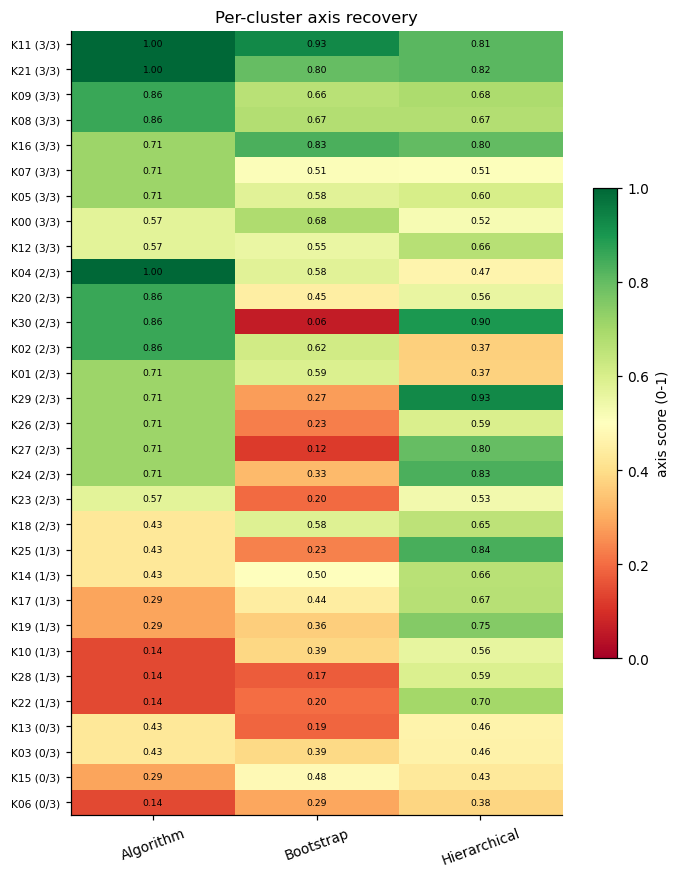

In [9]:
_cols = ["handle", "keywords", "axis1_score", "axis2_score"]
_cols += [c for c in ("rep_strict", "rep_dir", "axis3_score") if c in verdict.columns]
_cols += ["axis4_score", "n_axes_passed", "band"]
_title = ("Per-cluster axis profile" if cfg.axis3_enabled else
          f"Per-cluster profile over {int(verdict['n_axes_enabled'].iloc[0])} enabled axes "
          "(Axis 3 disabled; canonical verdict bands need the full four-axis protocol)")
reporting.show(verdict[_cols], n=40, title=_title)
_, fig = reporting.fig_axis_heatmap(cfg, verdict, cards); fig

## 5 · Domain structure

Two independently derived groupings over the same centroid geometry. Agreement
between them is a **geometric consistency check**, not independent validation —
and it is compared against a Monte-Carlo chance baseline.

[    5.1s] cache hit  iracing__domains.csv


[    6.3s] table   -> domain_assignment.csv  (31 rows)


[    6.3s] table   -> domain_keywords.csv  (4 rows)


[    6.3s] table   -> domain_summary.csv  (1 rows)


**Ward vs Louvain**

,n_domains_requested,louvain_communities,network_edges,network_density,ward_louvain_agreement,chance_baseline
0,4,7,81,0.174,0.6452,0.4004


**Derived domains, named by their own aggregated keywords**

,ward_group,n_clusters,n_sentences,domain_keywords
0,4,11,977,machine / steven / 77 / turn / 13 / corner
1,2,9,1341,laps / flag / racing / lap / car / track
2,1,6,598,look / happens / leader / friends / quick look / thank
3,3,5,649,position / seconds / place / seconds leader / second / leader


[    6.9s] figure  -> fig_dendrogram.png


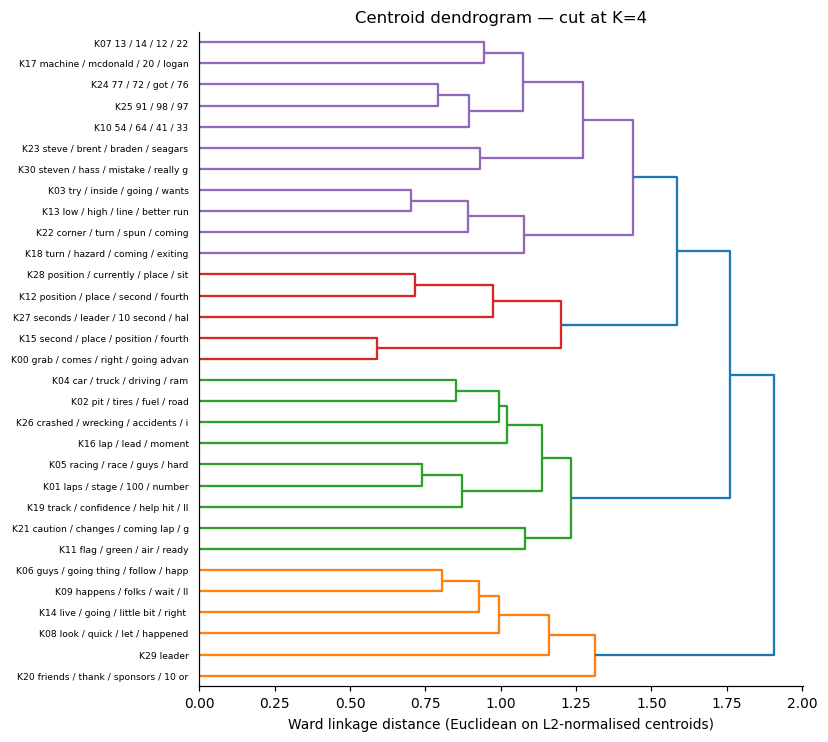

In [10]:
ids, C = clustering.centroids(X, labels)
dom, dom_summary, Z = domains.domain_analysis(cfg, ids, C, cards)
dom_kw = domains.domain_keywords(dom, enr)

save_table(cfg, dom, "domain_assignment")
save_table(cfg, dom_kw, "domain_keywords")
save_table(cfg, pd.DataFrame([dom_summary]), "domain_summary")

reporting.show(pd.DataFrame([dom_summary]), title="Ward vs Louvain")
reporting.show(dom_kw, title="Derived domains, named by their own aggregated keywords")
_, fig = reporting.fig_dendrogram(cfg, Z, cards, ids); fig

In [11]:
# Where the centroid hierarchy actually splits, and where a cut only sheds a singleton
cuts = domains.ward_cut_profile(C)
save_table(cfg, cuts, "ward_cut_profile")

# Agreement broken out per derived domain, so a good overall figure cannot hide a split group
per_dom = domains.per_group_agreement(dom)
per_dom = per_dom.merge(dom_kw[["ward_group", "domain_keywords"]], on="ward_group", how="left")
save_table(cfg, per_dom, "domain_agreement_breakdown")

reporting.show(cuts, n=12, title="Ward cut profile - group sizes at successive K")
reporting.show(per_dom, n=12, title="Ward vs Louvain, per derived domain")

[    7.2s] table   -> ward_cut_profile.csv  (7 rows)


[    7.2s] table   -> domain_agreement_breakdown.csv  (4 rows)


**Ward cut profile - group sizes at successive K**

,K,group_sizes,largest,smallest,singletons
0,2,"[25, 6]",25,6,0
1,3,"[16, 9, 6]",16,6,0
2,4,"[11, 9, 6, 5]",11,5,0
3,5,"[9, 7, 6, 5, 4]",9,4,0
4,6,"[9, 7, 5, 5, 4, 1]",9,1,1
5,8,"[7, 5, 5, 5, 4, 2, 2, 1]",7,1,1
6,10,"[7, 5, 4, 4, 3, 2, 2, 2, 1, 1]",7,1,2


**Ward vs Louvain, per derived domain**

,ward_group,n_clusters,louvain_counterpart,matched,match_pct,domain_keywords
0,4,11,1,5,45.5,machine / steven / 77 / turn / 13 / corner
1,2,9,5,5,55.6,laps / flag / racing / lap / car / track
2,1,6,4,5,83.3,look / happens / leader / friends / quick look / thank
3,3,5,2,5,100.0,position / seconds / place / seconds leader / second / leader


In [12]:
# Sub-structure inside the largest clusters, both ways: a fixed-K cut always returns
# sub-groups, while re-running the density clusterer inside the parent may return none.
subs = domains.subcluster_profile(cfg, X, U, labels, cards, df["masked"], top_n=3, k_sub=3)
save_table(cfg, subs, "subcluster_profile")
reporting.show(subs, n=20, title="Sub-partition of the three largest clusters")
print("density_subclusters = 0 would mean one mode rather than several themes;\n"
      "note it is computed in the reduced space, since HDBSCAN on the raw\n"
      "embeddings returns 100% noise for any input regardless of structure.")

[    7.7s] table   -> subcluster_profile.csv  (9 rows)


**Sub-partition of the three largest clusters**

,parent_handle,parent_size,sub_id,sub_size,share_of_parent,sub_keywords,density_subclusters,density_noise_pct
0,K00,397,1,63,0.159,folks / farther / continue / right / going,5,45.3
1,K00,397,2,114,0.287,let / going / look / right / grab,5,45.3
2,K00,397,3,220,0.554,right / trying / going / inside / lead,5,45.3
3,K01,321,1,203,0.632,laps / right / going / stage / end,4,24.9
4,K01,321,2,70,0.218,lap / 80 / 100 / number / right,4,24.9
5,K01,321,3,48,0.150,pitted / lap / stage / number / end,4,24.9
6,K02,272,1,152,0.559,pit / pits / road / coming / drivers,3,11.8
7,K02,272,2,53,0.195,fuel / guys / going / gas / tank,3,11.8
8,K02,272,3,67,0.246,tires / going / taking / outside / inside,3,11.8


density_subclusters = 0 would mean one mode rather than several themes;
note it is computed in the reduced space, since HDBSCAN on the raw
embeddings returns 100% noise for any input regardless of structure.


## 6 · Held-out coverage, leftover partition, shuffle null

Each held-out sentence is assigned to its **nearest cluster centroid** and
counted as covered above a cosine threshold. If no second-register corpus is
configured, sessions are split so coverage measures transfer to **unseen
sessions**. That is a weaker claim than transfer across registers, and is
labelled as such.

[    7.8s] holdout split: 4/8 sessions held out (3,191 sentences)


[    7.8s] table   -> coverage_per_session.csv  (4 rows)


[    7.8s] table   -> coverage_tau_sweep.csv  (5 rows)


[    7.8s] table   -> tau_characterisation.csv  (1 rows)


holdout: session-level split of the same corpus (4 sessions)
pooled coverage @ tau=0.4: 89.9%


...

**Threshold sensitivity**

,tau,pooled_coverage_pct,leftover_sentences
0,0.30,97.618301,76
1,0.35,94.641178,171
2,0.40,89.940458,321
3,0.45,83.641492,522
4,0.50,74.146036,825


**What the threshold does (recall floor, not a discriminator)**

,value
tau,0.400
retains_of_clustered_pct,96.370
clustered_below_tau,58.000
clustered_total,1598.000
p1_of_clustered,0.340
admits_of_noise_pct,73.090
youden_j,0.233
separation_optimal_tau,0.550
separation_optimal_j,0.518


[    8.1s] figure  -> fig_coverage.png


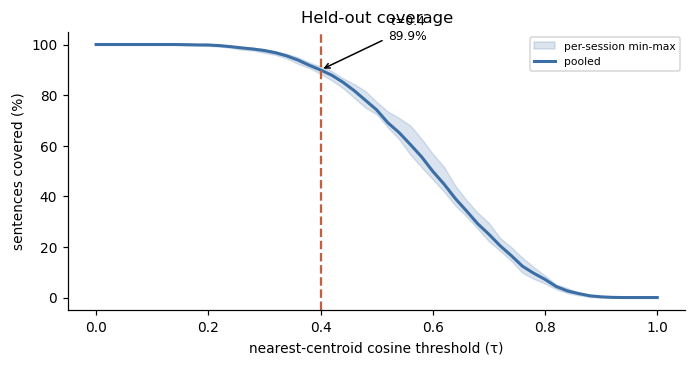

In [13]:
if cfg.heldout_sentences_path:
    held_df = corpus.apply_masking(
        cfg, corpus.load_corpus(cfg, cfg.heldout_sentences_path))   # separate corpus
    Xh = embedding.embed(cfg, held_df["masked"], tag="emb_heldout")
    sessions_h, holdout_kind = held_df["session"], "separate corpus (different register)"
    X_train, labels_train = X, labels
else:
    held_mask, held_names = coverage.make_heldout_split(cfg, df)
    Xh, sessions_h = X[held_mask], df.loc[held_mask, "session"]
    X_train, labels_train = X[~held_mask], labels[~held_mask]
    holdout_kind = f"session-level split of the same corpus ({len(held_names)} sessions)"

cov = coverage.coverage(cfg, Xh, C, sessions_h)
per_session = coverage.coverage_by_session(cov, cfg.coverage_tau)
sweep_tau = coverage.tau_sweep(cov, cfg.coverage_tau_sweep)
floor = coverage.threshold_floor(cfg, X_train, labels_train, C)

save_table(cfg, per_session, "coverage_per_session")
save_table(cfg, sweep_tau, "coverage_tau_sweep")
save_table(cfg, pd.DataFrame([floor]), "tau_characterisation")

print(f"holdout: {holdout_kind}")
print(f"pooled coverage @ tau={cfg.coverage_tau}: {100 * cov['covered'].mean():.1f}%")
reporting.show(per_session, n=20, title="Coverage per held-out session")
reporting.show(sweep_tau, title="Threshold sensitivity")
reporting.show(pd.DataFrame([floor]).T.rename(columns={0: "value"}),
               n=12, title="What the threshold does (recall floor, not a discriminator)")
_, fig = reporting.fig_coverage_curve(cfg, cov); fig

[    8.4s] cache hit  iracing__leftover.csv


[    8.4s] leftover: 2 clusters from 321 residual sentences


[    8.4s] cache hit  iracing__leftover_null.json


[    8.4s] table   -> leftover_clusters.csv  (2 rows)


[    8.4s] table   -> shuffle_null.csv  (1 rows)


residual sentences: 321
leftover clusters : 2   universal: 2
  observed_universal: 2
  null_mean: 2.0
  null_sd: 0.0
  null_range: [2, 2]
  iterations: 1000
  p_observed_or_fewer: 1.0
  p_observed_or_more: 1.0
  direction: not distinguishable from chance
  testable: True


**Leftover clusters by session spread**

,lc,size,sessions,universal
0,1,150,4,True
1,0,96,4,True


[    8.7s] figure  -> fig_leftover_spread.png


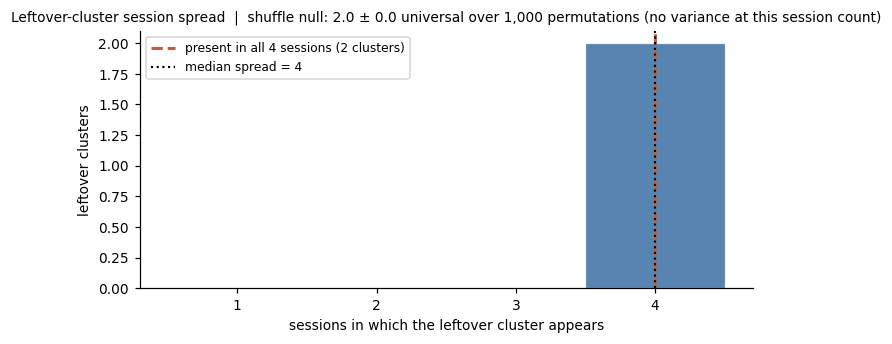

In [14]:
resid = ~cov["covered"].to_numpy()
left = coverage.leftover_partition(cfg, Xh[resid], cov.loc[resid, "session"])
uni, n_universal, n_lc = coverage.universality(left)
null = coverage.shuffle_null(cfg, left)
verdict_null = coverage.null_verdict(n_universal, null)

save_table(cfg, uni, "leftover_clusters")
save_table(cfg, pd.DataFrame([verdict_null]), "shuffle_null")

print(f"residual sentences: {int(resid.sum()):,}")
print(f"leftover clusters : {n_lc}   universal: {n_universal}")
for k, v in verdict_null.items():
    print(f"  {k}: {v}")
if n_lc:
    reporting.show(uni, n=20, title="Leftover clusters by session spread")
    _, fig = reporting.fig_null(cfg, uni, sessions_h.nunique(),
                                null, n_universal)
fig if n_lc and null.get("iterations") else None

## 7 · Intrinsic quality and judge sensitivity

Two checks on the partition itself rather than on individual clusters. DBCV is
the density-aware index; silhouette favours convex partitions and is reported as
a comparator. Both are scored only on the clustered fraction, which is printed
alongside — a pipeline that discards most of the corpus can post a flattering
score on the remainder.

In [15]:
alts = validation.alternative_partitions(cfg, X, U, labels, texts=df["masked"])

intrinsic = validation.intrinsic_indices(cfg, U, labels, alts)
loo = validation.loo_sensitivity(cfg, X, U, labels, alts)
noise = validation.noise_profile(cfg, X, labels, SOURCED, C, ids)

save_table(cfg, intrinsic, "intrinsic_indices")
save_table(cfg, loo, "loo_sensitivity")
save_table(cfg, noise, "noise_profile")

reporting.show(intrinsic, n=12, title="Intrinsic indices by pipeline")
reporting.show(loo, n=12, title="Leave-one-out: does any single judge carry the Axis-1 count?")
reporting.show(noise.T.rename(columns={0: "value"}), n=10,
               title="What is in the discarded noise bucket")

[    9.0s] cache hit  iracing__alt_enc_all.npy


[    9.0s] cache hit  iracing__alt_enc_bge.npy


[    9.0s] cache hit  iracing__alt_enc_gte.npy


[   20.3s] cache hit  iracing__umap_alt__s43.npy


[   20.3s] umap: (5967, 5)


...

,pipeline,n_clusters,noise_pct,scored_on_pct,silhouette,dbcv
0,primary (UMAP+HDBSCAN),31,40.3,59.7,0.6205,0.5485
1,enc_all,25,34.1,65.9,0.2203,-0.9239
2,enc_bge,36,37.3,62.7,0.0265,-0.8624
3,enc_gte,31,28.8,71.2,0.0458,-0.9455
4,kmeans,31,0.0,100.0,0.4207,-0.5993
5,ward,31,0.0,100.0,0.4025,-0.3836
6,optics,180,33.2,66.8,0.7090,0.5952
7,leiden,79,0.0,100.0,0.3608,NaN
8,res_mcs17,91,33.6,66.4,0.6925,0.6405
9,res_mcs52,8,14.6,85.4,0.4064,0.3190


**Leave-one-out: does any single judge carry the Axis-1 count?**

,removed,majority_count,delta,abs_delta
0,(none - all judges),19,0,0
1,enc_all,17,-2,2
2,enc_bge,19,0,0
3,enc_gte,18,-1,1
4,kmeans,17,-2,2
5,ward,17,-2,2
6,optics,19,0,0
7,leiden,17,-2,2
8,res_mcs17,19,0,0
9,res_mcs52,19,0,0


**What is in the discarded noise bucket**

,value
noise_sentences,2402
noise_pct,40.3
median_nearest_cosine,0.492
pct_above_coverage_tau,76.1
mean_token_count,16.1
least_similar_example,Each admin box connects via USB. [Friday Night O'Reilly Auto Part...
most_similar_example,Max the Flippy in third in on the back straightaway. [Friday Nigh...


## 8 · Ablations

**Masking** is asserted to decouple thematic structure from entity frequency —
here that assertion is measured. **Cross-encoder** re-derives the domain grouping
in an independent embedding space with a label-permutation test. **Default
pipeline** asks what an out-of-the-box run would have produced instead: library
default granularity, first on the same masked text, then on raw text.

Each ablation re-embeds the corpus; set `RUN_ABLATIONS = False` to skip.

In [16]:
if RUN_ABLATIONS:
    abl_mask = ablation.masking_ablation(cfg, df, labels)
    save_table(cfg, abl_mask, "ablation_masking")
    reporting.show(abl_mask.T.rename(columns={0: "value"}), n=12,
                   title="Masked vs unmasked partition")

    abl_enc = ablation.cross_encoder_stability(cfg, df, labels, ids, C, ALT_ENCODER)
    save_table(cfg, abl_enc, "ablation_cross_encoder")
    reporting.show(abl_enc.T.rename(columns={0: "value"}), n=12,
                   title="Domain structure across encoder families")

    abl_def = ablation.default_pipeline_ablation(cfg, df, U, labels, DEFAULT_MCS)
    save_table(cfg, abl_def, "ablation_default_pipeline")
    reporting.show(abl_def, n=12,
                   title=f"Chosen configuration vs library default (mcs={DEFAULT_MCS})")
else:
    print("ablations skipped (RUN_ABLATIONS = False)")

[   20.6s] cache hit  iracing__ablation_masking.csv


[   20.6s] table   -> ablation_masking.csv  (1 rows)


**Masked vs unmasked partition**

,value
comparison,masked vs unmasked
masked_clusters,31
unmasked_clusters,46
masked_noise_pct,40.3
unmasked_noise_pct,35.6
ari_all,0.3596
nmi_all,0.5515
ari_co_clustered,0.6282
n_co_clustered,2960


[   20.6s] cache hit  iracing__ablation_cross_encoder.csv


...

,value
encoder_a,all-MiniLM-L6-v2
encoder_b,all-mpnet-base-v2
n_domains,4
nmi,0.7795
best_mapping_agreement,0.8065
permutation_null_mean_nmi,0.1385
permutations,2000
p_value,0.0


[   20.6s] cache hit  iracing__ablation_default_pipeline.csv


[   20.6s] table   -> ablation_default_pipeline.csv  (2 rows)


**Chosen configuration vs library default (mcs=10)**

,variant,n_clusters,noise_pct,ari_all,nmi_all,ari_co_clustered,n_co_clustered
0,"default granularity (mcs=10), masked",148,25.8,0.1454,0.6044,0.5632,2932
1,"default granularity (mcs=10), unmasked",151,24.8,0.0983,0.4799,0.3387,2896


## 9 · Coverage confidence interval

Sessions are the resampling unit: sentences inside one broadcast are not
independent, so a sentence-level interval would be optimistically tight.

In [17]:
cov_ci = coverage.coverage_bootstrap_ci(cfg, cov, n_boot=10000)
save_table(cfg, cov_ci, "coverage_bootstrap_ci")
reporting.show(cov_ci.T.rename(columns={0: "value"}), n=12,
               title="Pooled coverage with session-level bootstrap CI")

[   21.1s] table   -> coverage_bootstrap_ci.csv  (1 rows)


**Pooled coverage with session-level bootstrap CI**

,value
tau,0.4
pooled_coverage_pct,89.94
bootstrap_mean_pct,89.91
ci95_lo,88.7
ci95_hi,91.0
ci_width_pp,2.3
sessions,4
per_session_min_pct,88.44
per_session_max_pct,91.33
resamples,10000


---

### Reproducing the published numbers

The same computational framework can be applied with the paper F1 configuration
and licensed F1 inputs. The F1 configuration enables the full four-axis
protocol; the shipped iRacing preset uses three axes by default. Canonical F1
numerical results are pinned by the released artefacts and regression
expectations.

```python
cfg = Config(
    corpus_name="f1_highlights",
    sentences_path=".../corpus_113races_masked_v4.json",
    session_field="race_id",
    heldout_sentences_path=".../fullrace_sentences.jsonl",  # the register holdout
    apply_masking=False,   # that corpus ships pre-masked
    min_cluster_size=35,
)
```

The notebook derives corpus-specific keyword handles and exemplar sentences
automatically. The thematic labels and broad-domain assignments reported in the
paper are human-authored reference artefacts and are not regenerated
automatically by the clustering pipeline.